In [3]:
''' Proyecto: DataProject: Proyecto EDA con PythonProyecto '''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


In [6]:
# Cargamos csv
datos_banco = pd.read_csv("../data/raw/bank-additional.csv", index_col=0)
datos_banco.head()

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_
0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,1,999,0,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,2-agosto-2019,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079
1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,14-septiembre-2016,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097
2,37.0,services,MARRIED,high.school,0.0,1.0,0.0,telephone,226,1,999,0,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,15-febrero-2019,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,40.0,admin.,MARRIED,basic.6y,0.0,0.0,0.0,telephone,151,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,29-noviembre-2015,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e
4,56.0,services,MARRIED,high.school,0.0,0.0,1.0,telephone,307,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,29-enero-2017,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


In [7]:
resumen_datos_banco = pd.DataFrame({
    "columna": datos_banco.columns,
    "tipo": datos_banco.dtypes.values,
    "nulos": datos_banco.isna().sum().values,
    "valores_unicos": datos_banco.nunique().values
})

resumen_datos_banco


,columna,tipo,nulos,valores_unicos
0,age,float64,5120,78
1,job,object,345,11
2,marital,object,85,3
3,education,object,1807,7
4,default,float64,8981,2
5,housing,float64,1026,2
6,loan,float64,1026,2
7,contact,object,0,2
8,duration,int64,0,1540
9,campaign,int64,0,42


In [8]:
# Se detectan muchos valores nulos, se completa la muestra con la mmediana de edades.

datos_banco["age"] = datos_banco["age"].fillna(
    datos_banco["age"].median()
)


# Se detectan tipos incorrectos en los siguientes campos, convertimos su tipo string en lugar de bool para completar los nulos con "desconocido".

bin_cols = ["default", "housing", "loan"]

for col in bin_cols:
    datos_banco[col] = datos_banco[col].astype("object")
    datos_banco[col] = datos_banco[col].fillna("desconocido")


# Se detectan tipos incorrectos en los siguientes campos, convertimos su tipo a float.

num_cols = [
    "cons.price.idx",
    "cons.conf.idx",
    "euribor3m",
    "nr.employed"
]

for col in num_cols:
    datos_banco[col] = pd.to_numeric(
        datos_banco[col].astype(str).str.replace(",", "."),
        errors="coerce"
    )


# Se detectan muchos valores nulos, se completa la muestra con la media y mediana para Indice de precios y Tasa de interes.

datos_banco["cons.price.idx"] = datos_banco["cons.price.idx"].fillna(
    datos_banco["cons.price.idx"].mean()
)

datos_banco["euribor3m"] = datos_banco["euribor3m"].fillna(
    datos_banco["euribor3m"].median()
)


# Se detectan muchos valores nulos, se completa la muestra con "desconocido" para Profesión, Nivel educativo y Estado civil.

cat_cols = ["job", "education", "marital"]

for col in cat_cols:
    datos_banco[col] = datos_banco[col].fillna("desconocido")


# Se detectan tipos incorrectos en fecha, convertimos su tipo a datetime.

# 1. Crear diccionario de meses en español a números
meses_es = {
    "enero": "01",
    "febrero": "02",
    "marzo": "03",
    "abril": "04",
    "mayo": "05",
    "junio": "06",
    "julio": "07",
    "agosto": "08",
    "septiembre": "09",
    "octubre": "10",
    "noviembre": "11",
    "diciembre": "12"
}

# 2. Función para convertir "2-agosto-2019" -> "2019-08-02"
def convertir_fecha(fecha):
    try:
        if pd.isna(fecha):
            return pd.NaT
        dia, mes, anio = fecha.split('-')
        mes_num = meses_es[mes.lower()]
        return pd.to_datetime(f"{anio}-{mes_num}-{int(dia):02d}")
    except:
        return pd.NaT

# 3. Aplica la función
datos_banco["date"] = datos_banco["date"].apply(convertir_fecha)

# 4. Mostrar en formato YYYY-MM-DD
datos_banco["date"] = datos_banco["date"].dt.strftime('%Y-%m-%d')



In [9]:
# Agrupacion de columnas numericas y detalle de valores

columnas_numericas = [
    "age",
    "duration",
    "campaign",
    "pdays",
    "previous",
    "emp.var.rate",
    "cons.price.idx",
    "cons.conf.idx",
    "euribor3m",
    "nr.employed"
]
datos_banco[columnas_numericas].describe()


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000
mean,39.741698,257.739279,2.567233,962.330953,0.174023,0.077128,93.574219,-40.509049,3.883541,5166.852602
std,9.817735,258.666033,2.772294,187.260394,0.497366,1.573898,0.576365,4.637186,1.621095,72.411125
min,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,33.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.466000,5099.100000
50%,38.000000,179.000000,2.000000,999.000000,0.000000,1.100000,93.574219,-41.800000,4.857000,5191.000000
75%,46.000000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.959000,5228.100000
max,98.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [10]:
# Alternativa para imputar valores a los nulos numericos.

imputaciones = {
    "age": "median",
    "euribor3m": "median",
    "cons.price.idx": "mean"
}

for col, metodo in imputaciones.items():
    if metodo == "median":
        datos_banco[col] = datos_banco[col].fillna(datos_banco[col].median())
    else:
        datos_banco[col] = datos_banco[col].fillna(datos_banco[col].mean())



In [11]:
# Alternativa para conversion a campos numericos.

def limpiar_columna_numerica(df, columna):
    df[columna] = (
        df[columna]
        .astype(str)
        .str.replace(",", ".", regex=False)
    )
    df[columna] = pd.to_numeric(df[columna], errors="coerce")
    return df

for col in ["euribor3m", "cons.price.idx", "cons.conf.idx", "nr.employed"]:
    datos_banco = limpiar_columna_numerica(datos_banco, col)



In [12]:
# Alternativa para imputar valores a los nulos string.

columnas_categoricas = ["job", "education", "marital"]

for col in columnas_categoricas:
    datos_banco[col] = datos_banco[col].fillna("desconocido")


In [13]:
# Tamaño final del dataset
datos_banco.shape


(43000, 23)

In [14]:
# Tipos de datos
datos_banco.dtypes


age               float64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
date               object
latitude          float64
longitude         float64
id_                object
dtype: object

In [15]:
# % de nulos finales
datos_banco.isnull().mean() * 100


age               0.000000
job               0.000000
marital           0.000000
education         0.000000
default           0.000000
housing           0.000000
loan              0.000000
contact           0.000000
duration          0.000000
campaign          0.000000
pdays             0.000000
previous          0.000000
poutcome          0.000000
emp.var.rate      0.000000
cons.price.idx    0.000000
cons.conf.idx     0.000000
euribor3m         0.000000
nr.employed       0.000000
y                 0.000000
date              0.576744
latitude          0.000000
longitude         0.000000
id_               0.000000
dtype: float64

In [16]:
datos_banco.describe().T


,count,mean,std,min,25%,50%,75%,max
age,43000.0,39.741698,9.817735,17.000,33.00000,38.000000,46.00000,98.000
duration,43000.0,257.739279,258.666033,0.000,102.00000,179.000000,319.00000,4918.000
campaign,43000.0,2.567233,2.772294,1.000,1.00000,2.000000,3.00000,56.000
pdays,43000.0,962.330953,187.260394,0.000,999.00000,999.000000,999.00000,999.000
previous,43000.0,0.174023,0.497366,0.000,0.00000,0.000000,0.00000,7.000
emp.var.rate,43000.0,0.077128,1.573898,-3.400,-1.80000,1.100000,1.40000,1.400
cons.price.idx,43000.0,93.574219,0.576365,92.201,93.07500,93.574219,93.99400,94.767
cons.conf.idx,43000.0,-40.509049,4.637186,-50.800,-42.70000,-41.800000,-36.40000,-26.900
euribor3m,43000.0,3.883541,1.621095,0.634,1.46600,4.857000,4.95900,5.045
nr.employed,43000.0,5166.852602,72.411125,4963.600,5099.10000,5191.000000,5228.10000,5228.100


In [17]:
categoricas = ["job", "marital", "education", "contact", "poutcome", "y"]

for col in categoricas:
    print("\n", col)
    print(datos_banco[col].value_counts(normalize=True))



 job
job
admin.           0.252860
blue-collar      0.224512
technician       0.163395
services         0.096791
management       0.070930
retired          0.041628
entrepreneur     0.035395
self-employed    0.034628
housemaid        0.026116
unemployed       0.024721
student          0.021000
desconocido      0.008023
Name: proportion, dtype: float64

 marital
marital
MARRIED        0.604628
SINGLE         0.281512
DIVORCED       0.111884
desconocido    0.001977
Name: proportion, dtype: float64

 education
education
university.degree      0.295860
high.school            0.230814
basic.9y               0.146721
professional.course    0.127372
basic.4y               0.101302
basic.6y               0.055488
desconocido            0.042023
illiterate             0.000419
Name: proportion, dtype: float64

 contact
contact
cellular     0.637116
telephone    0.362884
Name: proportion, dtype: float64

 poutcome
poutcome
NONEXISTENT    0.862860
FAILURE        0.103744
SUCCESS        0.033395


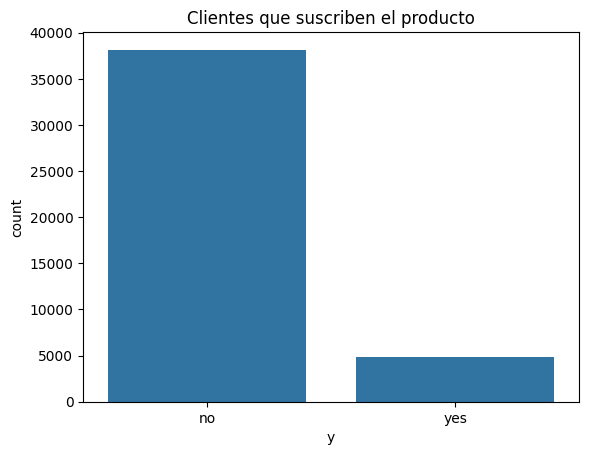

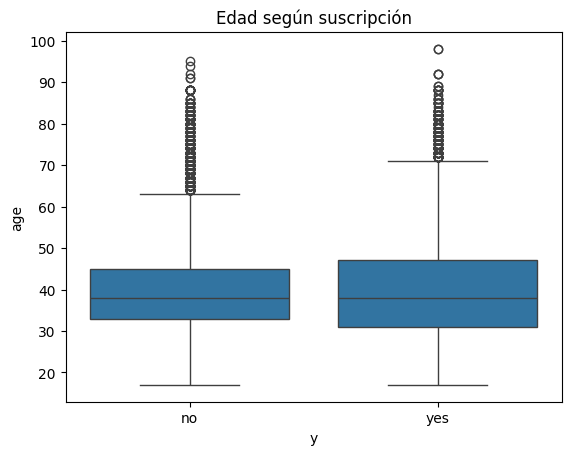

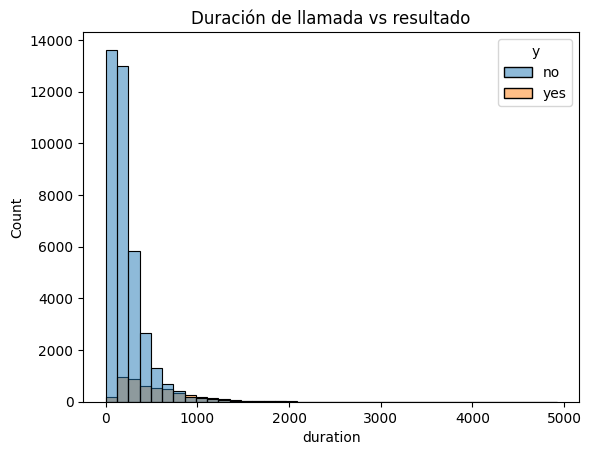

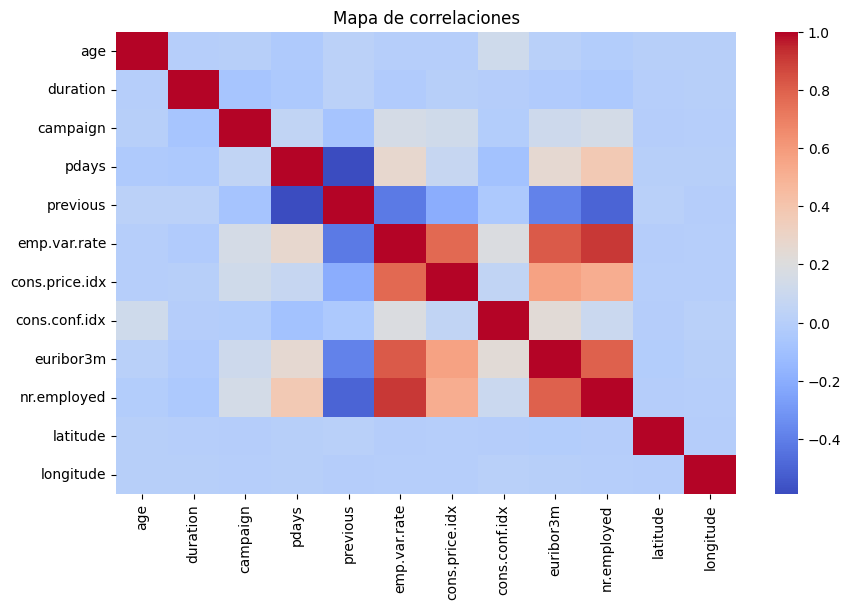

In [18]:
sns.countplot(x="y", data=datos_banco)
plt.title("Clientes que suscriben el producto")
plt.show()

sns.boxplot(x="y", y="age", data=datos_banco)
plt.title("Edad según suscripción")
plt.show()

sns.histplot(data=datos_banco, x="duration", hue="y", bins=40)
plt.title("Duración de llamada vs resultado")
plt.show()


corr_matrix = datos_banco.select_dtypes(include="number").corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.title("Mapa de correlaciones")
plt.show()



In [19]:
conversion_job = pd.crosstab(datos_banco["job"], datos_banco["y"], normalize="index")
conversion_job.sort_values("yes", ascending=False)


y,no,yes
job,,
student,0.686600,0.313400
retired,0.748045,0.251955
unemployed,0.856068,0.143932
admin.,0.869861,0.130139
desconocido,0.886957,0.113043
management,0.887869,0.112131
technician,0.891546,0.108454
self-employed,0.891874,0.108126
housemaid,0.901158,0.098842


In [20]:
datos_banco.groupby("y")["age"].mean()


y
no     39.640109
yes    40.541908
Name: age, dtype: float64

In [23]:
# Cargamos excel
xls = pd.ExcelFile("../data/raw/customer-details.xlsx")
dfs = []

for sheet in xls.sheet_names:
    df = pd.read_excel(xls, sheet_name=sheet)
    dfs.append(df)

datos_clientes = pd.concat(dfs, ignore_index=True)

datos_clientes.tail()

,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
43165,14085,156980,1,2,2014-05-17,7,5f432048-d515-4bb5-9c94-62db451f88d4
43166,14086,139820,0,0,2014-09-29,1,993bbbd6-4dbc-4a40-a408-f91f8462bee6
43167,14087,78470,2,2,2014-10-28,12,d6271666-319d-42c8-a741-cb22bf2c2093
43168,14088,144218,0,1,2014-07-01,9,f67fbfa8-6573-414d-a805-b26a2f1b1ceb
43169,14089,115155,0,2,2014-12-25,7,9727bc06-c11a-461a-a5bb-3d210467cc2a


In [24]:
resumen_datos_clientes = pd.DataFrame({
    "columna": datos_clientes.columns,
    "tipo": datos_clientes.dtypes.values,
    "nulos": datos_clientes.isna().sum().values,
    "valores_unicos": datos_clientes.nunique().values
})

resumen_datos_clientes

,columna,tipo,nulos,valores_unicos
0,Unnamed: 0,int64,0,20115
1,Income,int64,0,38310
2,Kidhome,int64,0,3
3,Teenhome,int64,0,3
4,Dt_Customer,datetime64[ns],0,1096
5,NumWebVisitsMonth,int64,0,32
6,ID,object,0,43170


In [32]:
import os

# Crear la carpeta processed si no existe
os.makedirs("../data/processed", exist_ok=True)

# Guardar CSV en processed
datos_banco.to_csv("../data/processed/bank_clean.csv", index=False)

# Guardar Excel en processed
datos_clientes.to_excel("../data/processed/customers_clean.xlsx", index=False)

print("Archivos guardados correctamente en data/processed ✅")

Archivos guardados correctamente en data/processed ✅


In [33]:
df_final = datos_banco.merge(
    datos_clientes,
    left_on="id_",
    right_on="ID",
    how="left"
)
df_final.head()

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,38.0,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191.0,no,2019-08-02,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079,0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079
1,57.0,services,MARRIED,high.school,desconocido,0.0,0.0,telephone,149,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191.0,no,2016-09-14,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097,1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097
2,37.0,services,MARRIED,high.school,0.0,1.0,0.0,telephone,226,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191.0,no,2019-02-15,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b,2,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,40.0,admin.,MARRIED,basic.6y,0.0,0.0,0.0,telephone,151,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191.0,no,2015-11-29,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e,3,121393,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e
4,56.0,services,MARRIED,high.school,0.0,0.0,1.0,telephone,307,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191.0,no,2017-01-29,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,4,63164,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


In [34]:
df_final.info()
df_final.describe()
df_final.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   age                43000 non-null  float64       
 1   job                43000 non-null  object        
 2   marital            43000 non-null  object        
 3   education          43000 non-null  object        
 4   default            43000 non-null  object        
 5   housing            43000 non-null  object        
 6   loan               43000 non-null  object        
 7   contact            43000 non-null  object        
 8   duration           43000 non-null  int64         
 9   campaign           43000 non-null  int64         
 10  pdays              43000 non-null  int64         
 11  previous           43000 non-null  int64         
 12  poutcome           43000 non-null  object        
 13  emp.var.rate       43000 non-null  float64       
 14  cons.p

age                    0
job                    0
marital                0
education              0
default                0
housing                0
loan                   0
contact                0
duration               0
campaign               0
pdays                  0
previous               0
poutcome               0
emp.var.rate           0
cons.price.idx         0
cons.conf.idx          0
euribor3m              0
nr.employed            0
y                      0
date                 248
latitude               0
longitude              0
id_                    0
Unnamed: 0             0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
NumWebVisitsMonth      0
ID                     0
dtype: int64

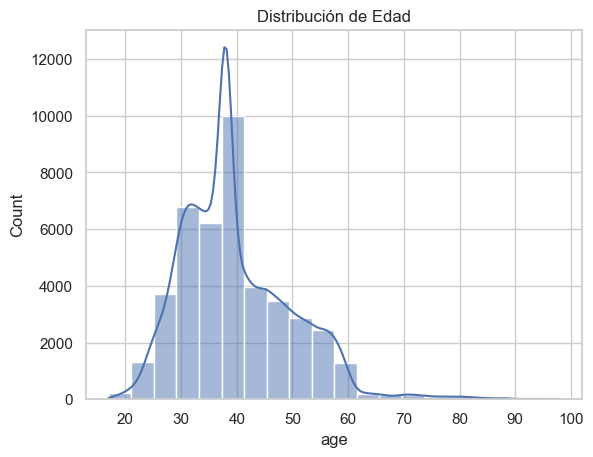

C:\Users\user\AppData\Local\Temp\ipykernel_15812\2980880069.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_final, x='y', palette='viridis')


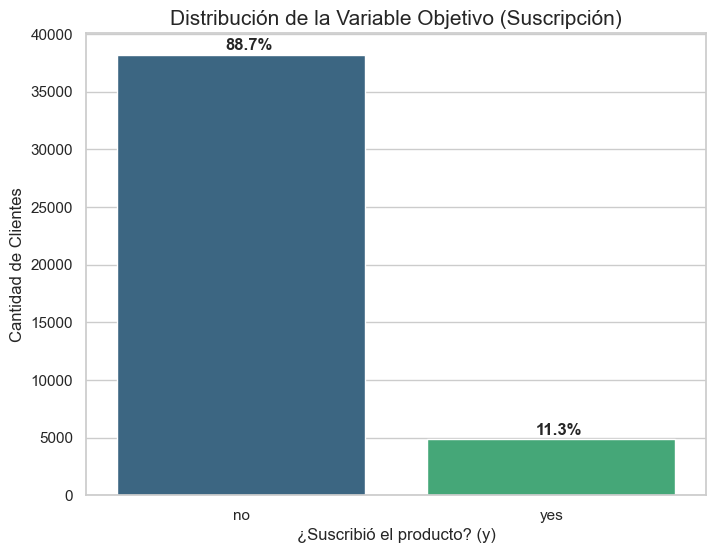

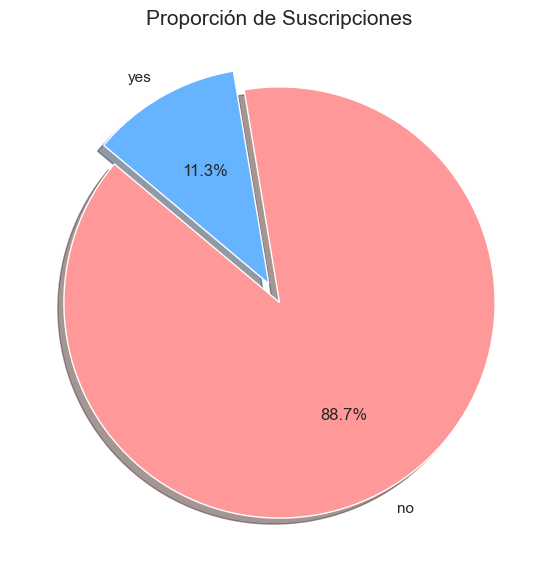

In [40]:
# Distribución de edades
sns.histplot(df_final['age'], bins=20, kde=True)
plt.title('Distribución de Edad')
plt.show()


sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# Crear el gráfico de barras
ax = sns.countplot(data=df_final, x='y', palette='viridis')

# Añadir títulos y etiquetas
plt.title('Distribución de la Variable Objetivo (Suscripción)', fontsize=15)
plt.xlabel('¿Suscribió el producto? (y)', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)

# Calcular porcentajes y mostrarlos sobre las barras
total = len(df_final['y'])
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height() + (total * 0.01)
    ax.annotate(percentage, (x, y), fontsize=12, fontweight='bold')

plt.show()

# Contar los valores
target_counts = df_final['y'].value_counts()

# Crear el gráfico de pastel
plt.figure(figsize=(7, 7))
plt.pie(target_counts, 
        labels=target_counts.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=['#ff9999','#66b3ff'], 
        explode=(0, 0.1), # Resalta la porción del "yes"
        shadow=True)

plt.title('Proporción de Suscripciones', fontsize=15)
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_15812\2987746272.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='marital', y='age', palette='Set2')


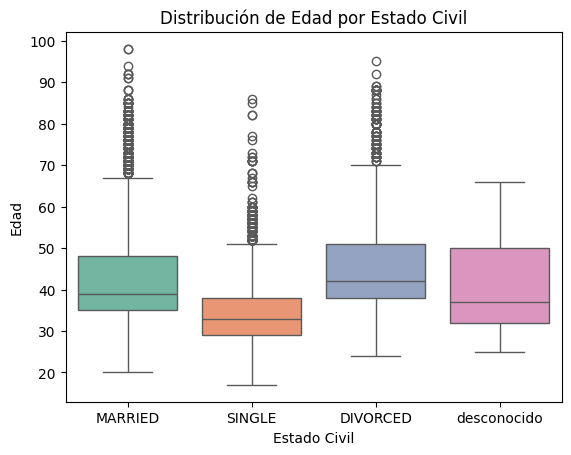

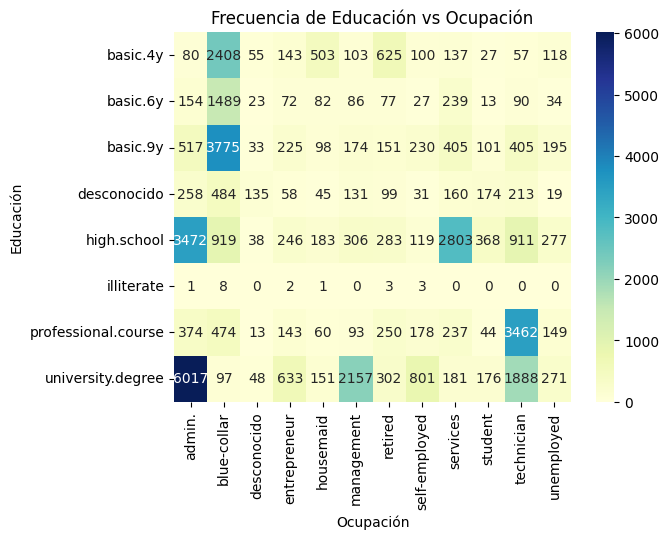

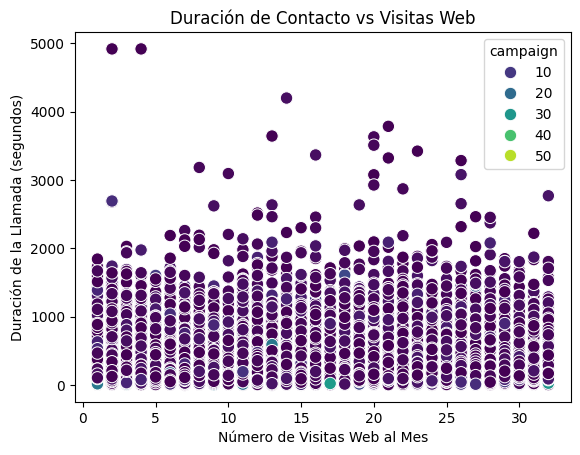

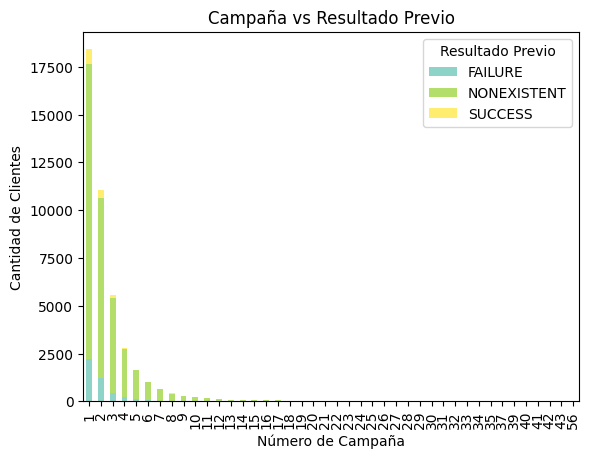

In [36]:


# -------------------------------
#  Distribución de Edad por Estado Civil
plt.figure()
sns.boxplot(data=df_final, x='marital', y='age', palette='Set2')
plt.title('Distribución de Edad por Estado Civil')
plt.xlabel('Estado Civil')
plt.ylabel('Edad')
plt.show()

# -------------------------------
#  Educación vs. Ocupación (Heatmap de Conteos)
edu_job_counts = pd.crosstab(df_final['education'], df_final['job'])
plt.figure()
sns.heatmap(edu_job_counts, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Frecuencia de Educación vs Ocupación')
plt.xlabel('Ocupación')
plt.ylabel('Educación')
plt.show()


# -------------------------------
#  Duración de Contacto vs Visitas Web
plt.figure()
sns.scatterplot(data=df_final, x='NumWebVisitsMonth', y='duration', hue='campaign', palette='viridis', s=80)
plt.title('Duración de Contacto vs Visitas Web')
plt.xlabel('Número de Visitas Web al Mes')
plt.ylabel('Duración de la Llamada (segundos)')
plt.show()

# -------------------------------
#  Campaña vs Resultado Previo
campaign_poutcome = pd.crosstab(df_final['campaign'], df_final['poutcome'])
campaign_poutcome.plot(kind='bar', stacked=True, colormap='Set3')
plt.title('Campaña vs Resultado Previo')
plt.xlabel('Número de Campaña')
plt.ylabel('Cantidad de Clientes')
plt.legend(title='Resultado Previo')
plt.show()
